# Minería de Datos
## | U6: Metodos de Ensamble - Random Forest Classifier
| Tec. Universitaria en Inteligencia Artificial.  
| 2025  

# Preparación del entorno

In [2]:
# Instalar la librería si no está instalada (descomentar si es necesario)
# %pip install scikit-learn
# %pip install matplotlib
#!pip install seaborn

In [3]:
import pandas as pd
import os
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn import metrics

In [4]:
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv('./data/Gas_Sensors_Measurements.csv')

In [5]:
def plot_multiple_conf_matrices(y_real_list, y_pred_list, titles):      
    '''
    **Plotea multiples matrices de confusiones con sus respectivos titulos.**
    ------------------------
    **Parámetros:**
    - y_real_list : lista de y reales.
    - y_pred_list: lista de y predichos.
    - titles: lista de titulos.

    -------------------------
    **Observaciones:**
    
    El orden de los contenidos de las listas deben coincidir entre sí.
    
    Por ejemplo:
    y_real_list = [y_test_1, y_test_2, y_test_3]
    y_pred_list = [y_test_1_pred, y_test_2_pred, y_test_3_pred]
    titles = ['Y test 1 conf. matrix', 'Y test 2 conf. matrix',  'Y test 3 conf. matrix']

    '''

    num_matrices = len(y_real_list)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    # Lista de colormaps para seleccionar aleatoriamente
    colormaps = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'coolwarm', 'cividis', 'magma']
    for i in range(num_matrices):
        color = random.choice(colormaps)
        cm = metrics.confusion_matrix(y_real_list[i], y_pred_list[i])
        sns.heatmap(cm, annot=True, ax=axes[i], fmt='d', cmap=color)
        axes[i].set_title(titles[i])
        axes[i].set_xlabel('Predicted labels')
        axes[i].set_ylabel('True labels')

    # Oculta cualquier eje restante si hay menos de 4 matrices
    for j in range(num_matrices, 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [6]:
def pd_metricas_clasifier(dict_modelos:dict, m_type: str = 'clasifier') -> pd.DataFrame:
    '''
    **Devuelve un df con métricas de evaluación básicas para arboles de regression y clasificación.**
    
    ---------------------
    **Parámetros**

    - dict_modelos: diccionario con la información de uno o más arboles asi como sus y_real e y_pred.
    - m_type: tipo de clasificación ['clasifier', 'regressor'] seteado a 'clasifier'

    --------------------
    **Estructura de  dict_modelo**

    La estructura de dict_modelos es la siguiente:

    dict_modelo = {

    'Nombre_modelo' : [

    [Max_produndidad, Min_obs, Min_Obs_x_Sep, Criterio_sep],

    (y_real,y_pred)]

    }

    ----------------------
    **Metricas Clasificacion:**

    Estan todas seteadas en 'weighted' para que sirva para multiclase.
    - Precision
    - Recall
    - Accuracy
    - F1-Score 

    **Metricas Regresión:**

    - MAE: Mean absolute Error.
    - MSE: Mean Squeared Error.
    - RMSE: Root Mean Squeared Error.


    '''
    metricas_modelos = pd.DataFrame()    
    for key,value in dict_modelos.items():
        valores_modelo = value[0]
        metrica_clas = {
        'Nombre_Modelo': key,
        'Max_profundidad' : valores_modelo[0],
        'Min_obs' : valores_modelo[1],
        'Min_Obs_x_Sep' : valores_modelo[2],
        'Criterio_Sep' : valores_modelo[3]
        }
        if m_type == 'clasifier':
            for i in range(1,len(value)):
                y_real,y_pred = value[i]
                metrica_clas[f'Precision Test {i}'] = precision_score(y_real,y_pred, average='weighted'),
                metrica_clas[f'Recall Test {i}'] = recall_score(y_real,y_pred, average='weighted')
                metrica_clas[f'Accuracy Test {i}'] = accuracy_score(y_real,y_pred),
                metrica_clas[f'F1-Score Test {i}'] = f1_score(y_real,y_pred, average='weighted')
        elif m_type == 'regressor':
            for i in range(1,len(value)):
                y_real,y_pred = value[i]
                metrica_clas[f'MAE Test {i}'] = mean_absolute_error(y_real,y_pred),
                metrica_clas[f'MSE Test {i}'] = mean_squared_error(y_real,y_pred)
                metrica_clas[f'RMSE Test {i}'] = np.sqrt(mean_squared_error(y_real,y_pred)),
        metricas_modelos = pd.concat([metricas_modelos,pd.DataFrame(metrica_clas)])
    
    return metricas_modelos

# Análisis descriptivo

 The dataset is collected using the seven different metal oxide gas sensors, MQ2, MQ3, MQ5, MQ6, MQ7, MQ8, MQ135 and a thermal imaging camera. The dataset consists of numerical values taken from gas sensors and images taken using a thermal camera.

El dataset fue obtenido de Kaggle: [https://www.kaggle.com/datasets/aryashah2k/multimodal-gas-detection-and-classification](https://www.kaggle.com/datasets/aryashah2k/multimodal-gas-detection-and-classification)

Para el propósito nuestro, sólo usaremos las medidas y no así las imágenes.

In [7]:
df = df.drop(['Corresponding Image Name', 'Serial Number'], axis = 1)

In [8]:
df.head()

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,555,515,377,338,666,451,416,NoGas
1,555,516,377,339,666,451,416,NoGas
2,556,517,376,337,666,451,416,NoGas
3,556,516,376,336,665,451,416,NoGas
4,556,516,376,337,665,451,416,NoGas


## Visualización tipo de datos.

Este paso es importante para verificar que los datos estén en su datatype correspondiente.

In [9]:
df.dtypes

MQ2       int64
MQ3       int64
MQ5       int64
MQ6       int64
MQ7       int64
MQ8       int64
MQ135     int64
Gas      object
dtype: object

En este caso, están correctamente en su datatype. Si hubiese alguna medición de un sensor como object, deberíamos convertirlo respectivamente.

## Visualización de Nulls

La visualización de datos nulos es muy importante ya que, de haberlos, se debe optar por una estrategia de imputación.

Podemos hacer un chequeo general simplemente con:

In [10]:
df.isnull().any().sum()

np.int64(0)

Constatamos que no hay datos faltantes en todo el dataset. Sin embargo, en la práctica real, es recomendable tener siempre una estrategia de imputación de nulos ya que se puede presentar un valor nuevo con datos de este tipo y debemos saber cómo imputarlo.

En este caso, si un senesor se rompe, o falla, el modelo seguiría necesitando el valor de este sensor para predecir.

En caso de que haya null en nuestra columna objetivo deberíamos descartarla ya que no ayudaría a la predicción del modelo.

## División en train-test

Dividimos el dataset antes de continuar con nuestro análisis descriptivo ya que simulamos una situación real en la que sólo contaríamos con train.

In [11]:
X = df.drop(['Gas'], axis = 1)
y = df['Gas']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [13]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4480, 7) (4480,)
(1920, 7) (1920,)


## Visualización de Outliers.

Como ya sabemos, un primer approach para ver datos faltantes es visualizarlos en un boxplot.

In [14]:
cols = X.columns.tolist()

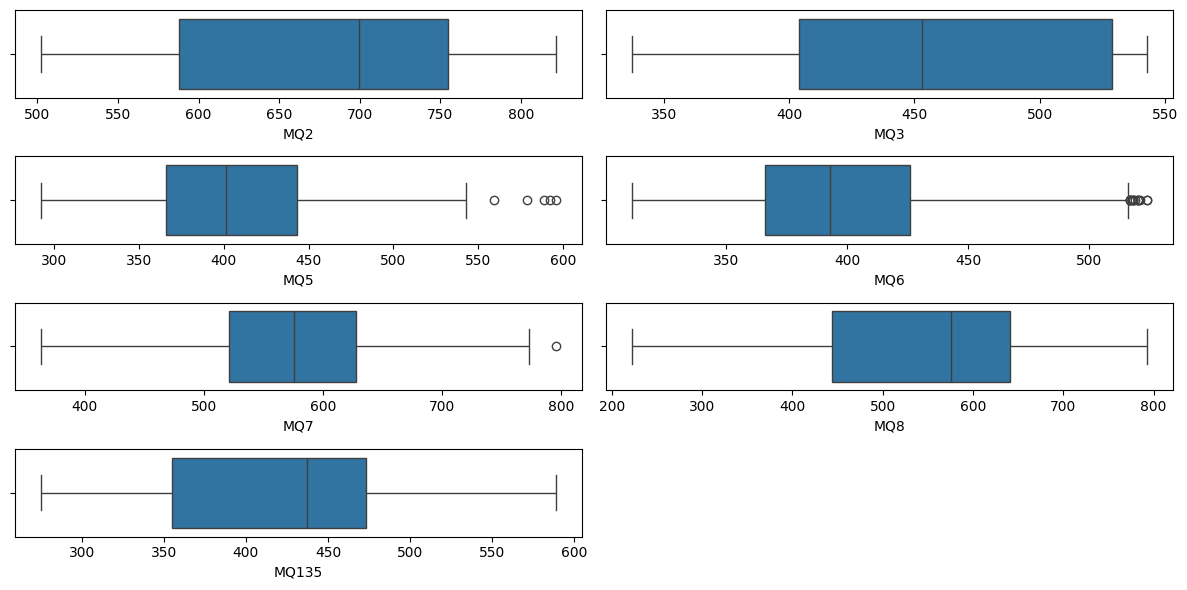

In [15]:
# Crear un lienzo con dos subplots uno al lado del otro
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
k = 0
for i in range(0,4):
    for j in range(0,2):
      if k > len(cols)-1:
        break
      else:
        # Seleccionar la columna correspondiente
            sns.boxplot(x=X_train[cols[k]], ax=axes[i,j])
        # Incrementar el índice de la columna
            k += 1
            
#Quitamos ultimo cuadro ya que son 7 columnas
axes[3,1].axis('off')
plt.tight_layout()
plt.show()

Observamos que los sensores MQ5, MQ6 y MQ7 presentan valores atípicos.

### **❓ Podríamos afirmar con esta visualización que son valores atípicos?**

A primera vista podría ser tentador afirmarlo y deshacernos o tratarlos directamente.   
Pero no siempre es así.  
🔴 A veces si contrastamos una variable X con atípicos con otra variable Y, podríamos observar que ese atípico en X no lo es en comparación con ciertos valores dados en Y.

¿Cómo lo chequeamos? 

Una forma, es hacer un histograma con hue.

In [16]:
X_train_join = pd.concat([X_train, y_train], axis = 1)

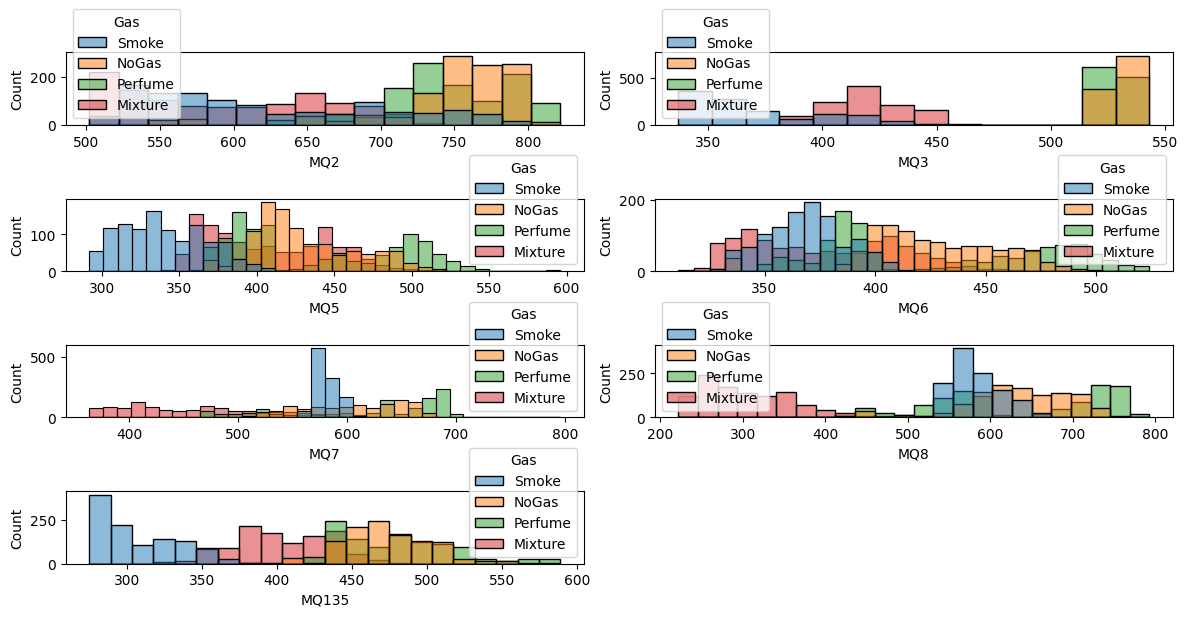

In [17]:
# Crear un lienzo con dos subplots uno al lado del otro
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
k = 0
for i in range(0,4):
    for j in range(0,2):
      if k > len(cols)-1:
        break
      else:
        # Seleccionar la columna correspondiente
            sns.histplot(x=X_train_join[cols[k]], ax=axes[i,j], hue=X_train_join['Gas' ],legend = True)
        # Incrementar el índice de la columna
            k += 1
#Quitamos ultimo cuadro ya que son 7 columnas
axes[3,1].axis('off')
plt.tight_layout()
plt.show()

### **❓¿Qué observamos?**

Esos atípicos que nos parecían tales a raíz de los gráficos boxplot en realidad no lo son. Podemos observar que:
- MQ5: los valores altos (aprox +500) son un comportamiento común para el gas 'Perfume'
- MQ6: los valores altos (aprox +470) son un comportamiento común para el gas 'Perfume'
- MQ7: los valores bajos (aprox -450) son un comportamiento común para el gas 'Mixture', mientras que los calores más altos (apeox +680) son valores comúnes para el gas 'Perfume'.

### **❓¿Qué podría haber pasado si hubiéramos optado por eliminarlos?**

🔴 **Pérdida de patrones importantes:**  hubiéramos eliminado también comportamientos reales y significativos del sensor ante ciertos gases, como Perfume o Mixture. Esto habría afectado la capacidad del modelo para aprender esos patrones y predecir correctamente en presencia de esos gases.

🔴 **Reducción de la representatividad del dataset:** Se reduce la diversidad de situaciones en los datos, lo que provoca un modelo sesgado hacia los casos más “típicos” (centrales), y menos robusto en la práctica.  

🔴 **Errores de generalización:** Un modelo entrenado con esos datos podría fallar ante entradas reales que sí incluyan esos valores altos o bajos, simplemente porque no los ha visto nunca durante el entrenamiento.  

🔴 **Falsa impresión de limpieza:** El dataset parecería más “limpio”, pero en realidad estaría incompleto y desbalanceado desde el punto de vista del fenómeno que intenta representar.  

### **🟢 Decisión.**

Dado el análisis anterior, se decide conservar aquellos valores, ya que se evidencia que, bajo ciertas categorías de gas, son en realidad valores comunes.

## Balanceo de clases.

<Axes: >

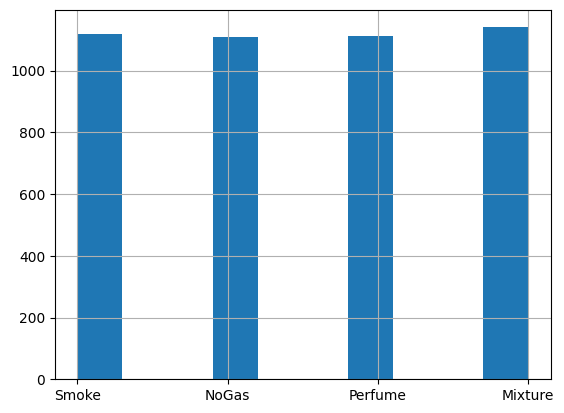

In [18]:
y_train.hist()

Observamos que las clases están balanceadas por lo que no es necesario realizar ningún tratamiento en cuanto a balanceo de clases.

## Otros análisis.

Veamos las medidas de las distintas variables.

In [19]:
X_train.describe()

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
count,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000
mean,676.129464,461.510268,404.567187,399.674107,565.288170,540.756920,416.263839
std,93.420885,70.307883,55.357935,44.848474,83.511057,151.414339,76.257376
min,502.000000,337.000000,292.000000,311.000000,363.000000,222.000000,275.000000
25%,588.000000,404.000000,366.000000,366.000000,521.000000,443.750000,354.750000
50%,699.500000,453.000000,401.000000,393.000000,576.000000,576.000000,437.000000
75%,755.000000,529.000000,443.000000,426.000000,628.000000,641.000000,473.000000
max,822.000000,543.000000,596.000000,524.000000,796.000000,793.000000,589.000000


- MQ2: 
    - Media: 677.95. La media de las mediciones de este sensor es relativamente alta, lo que indica que en promedio está midiendo valores elevados.
    - Desviación estándar: 92.74. Es una desviación estandar alta a comparación de las desviaciones de otros sensores.
    - Máximo: 824: El valor máximo es bastante alto, lo que indica que el sensor puede registrar concentraciones de gas muy elevadas.
    - El primer cuartil (25%) es 592, la mediana (50%) es 701 y el tercer cuartil (75%) es 756, lo que muestra que la distribución está sesgada ligeramente hacia la derecha, con una concentración de valores más altos hacia el extremo superior de la escala.

- MQ3: 
    - Media: 462.13. La media es menor que la del MQ2, lo que indica que en promedio este sensor mide concentraciones de gas más bajas que el MQ2.
    - Desviación estándar: 70.42. La desviación estándar es menor que la del MQ2, lo que sugiere que las lecturas de este sensor son más consistentes/concentradas.
    - Mínimo: 337. El valor mínimo es relativamente alto, lo que sugiere que este sensor no registra lecturas tan bajas como el MQ8 o MQ135. Podría estar calibrado para detectar un rango de concentraciones de gas más específico.
    - Máximo: 538. El valor máximo es más bajo que el de MQ2, lo que indica que las mediciones extremas de este sensor no son tan altas.
    - Cuartiles: El primer cuartil (25%) es 405, la mediana (50%) es 515 y el tercer cuartil (75%) es 444, lo que indica que la distribución es bastante estrecha y concentrada alrededor de valores medianos.

- MQ5:
    - Media: 405. Este sensor tiene una media de que es menor que la de los sensores MQ2 y MQ3, lo que podría indicar una menor sensibilidad o un rango diferente de medición.
    - Desviación estándar: 55. La desviación estándar es relativamente baja, lo que sugiere que las mediciones son bastante consistentes y estables.
    - Mínimo 291 y Máximo 595: La distancia entre el valor mínimo y máximo es más baja que el de los sensores MQ2 y MQ3, lo que puede reflejar una capacidad de medición más limitada o un rango de concentración de gas más restringido.
    - Cuartiles: El primer cuartil (25%) es 366, la mediana (50%) es 400 y el tercer cuartil (75%) es 444, lo que muestra una distribución más centrada y una menor dispersión.

- MQ6:  
    - Media: 400. Similar a MQ5.
    - Desviación estándar: 45.36. La desviación estándar es la más baja de todos los sensores, indicando que este sensor tiene las mediciones más consistentes y estables.
    - Cuartiles: El primer cuartil (25%) es 366, la mediana (50%) es 396 y el tercer cuartil (75%) es 427, lo que muestra que la distribución es bastante compacta y centrada alrededor de valores cercanos.

- MQ7:
    - Media: 566 MQ6.
    - Desviación estándar: 87. Tiene una desviación estandar más alta con respecto a los dos sensores anteriores, indicando que sus mediciones abarcan mayor rango.
    - Cuartiles: El primer cuartil (25%) es 523, la mediana (50%) es 576 y el tercer cuartil (75%) es 631, lo que también muestra una distribución concentrada.

- MQ8: 
    - Media: 543. Es más alta que la de los sensores MQ6 y MQ5, lo que sugiere que mide concentraciones de gas más altas en promedio.
    - Desviación estándar: 151. Tiene una desviación estándar alta en relación al resto de los sensores, indicando que las mediciones varían de manera más notable.
    - Mínimo 220 y Máximo 794: Este sensor mide rangos más amplios que los anteriores, a excepción de MQ2.
    - Cuartiles: el primer cuartil (25%) es 449, la mediana (50%) es 576 y el tercer cuartil (75%) es 643, lo que muestra una distribución de valores más dispersa que en otros sensores.

- MQ135:
    - Media: 417.10. La media de este sensor es moderada en relación a los otros sensores.
    - Desviación estándar: 76.87. La desviación estándar es mediana en relación a los otros sensores, indicando una dispersión media.
    - Mínimo: 275 y Máximo 589. Tiene un rango de mediciones más amplio que los otros, a excepción de MQ2.
    - Cuartiles: El primer cuartil (25%) es 355, la mediana (50%) es 437 y el tercer cuartil (75%) es 474, lo que muestra que hay una distribución de valores bastante variada y centrada en el rango medio.


Cada sensor tiene características distintivas en cuanto a su rango de medición y consistencia. Los sensores MQ6 y MQ7 presentan las desviaciones estándar más bajas, lo que indica que son más estables en sus mediciones.  
En cambio, los sensores MQ2 y MQ135 muestran una mayor variabilidad y sensibilidad, lo que podría hacerlos más adecuados para detectar una gama más amplia de concentraciones de gas. Además, los valores de los cuartiles indican que algunos sensores, como el MQ2, tienden a estar más concentrados en valores altos, mientras que otros, como el MQ6, tienen distribuciones más uniformes y compactas.

## Correlaciones

### Pearson

<Axes: >

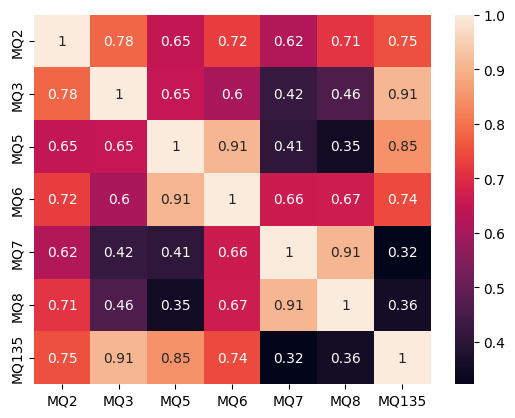

In [20]:
sns.heatmap(X_train.corr(method='pearson'),annot= True )

| Variables relacionadas      | Correlación |
|----------------------------|-------------|
| **MQ5 - MQ6**              | 0.91        |
| **MQ3 - MQ135**            | 0.91        |
| **MQ7 - MQ8**              | 0.90        |
| **MQ5 - MQ135**            | 0.85        |

### Spearman

<Axes: >

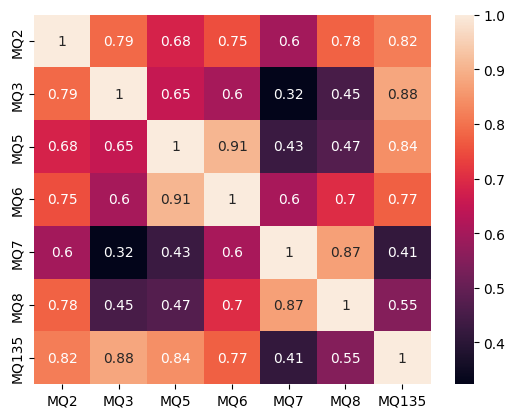

In [21]:
sns.heatmap(X_train.corr(method='spearman'),annot= True )

| Variables relacionadas      | Correlación de Spearman (ρ) |
|----------------------------|-----------------------------|
| **MQ5 - MQ6**              | 0.91                        |
| **MQ3 - MQ135**            | 0.88                        |
| **MQ2 - MQ135**            | 0.82                        |
| **MQ7 - MQ8**              | 0.87                        |

🔹 **Correlación de Pearson**  
- Mide relaciones lineales entre dos variables.
- Supone que las variables tienen distribución normal (o al menos simétrica).
- Es sensible a valores atípicos.
- Útil cuando se espera que un cambio en una variable provoque un cambio proporcional en la otra.

Ejemplo: Si al aumentar el gas A en el ambiente, el sensor X sube en la misma proporción, Pearson lo captará bien.  



🔹 **Correlación de Spearman**  
- Mide la relación monotónica entre variables, es decir, si una variable tiende a aumentar o disminuir cuando la otra lo hace, sin importar la forma exacta de la relación.
- Se basa en los rangos de los datos, no en los valores reales.
- No requiere normalidad ni linealidad.
- Es más robusta frente a valores atípicos.

**Ejemplo: Si el sensor Y siempre aumenta cuando aumenta el gas B, pero no de forma constante, Spearman puede captarlo aunque Pearson no.**

# Metodo de ensamble : Random forest

In [22]:
X_train.columns

Index(['MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135'], dtype='object')

In [23]:
rf = RandomForestClassifier(random_state= 11)
rf.fit(X_train,y_train)

y_rf_pred = rf.predict(X_test)

In [24]:
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree

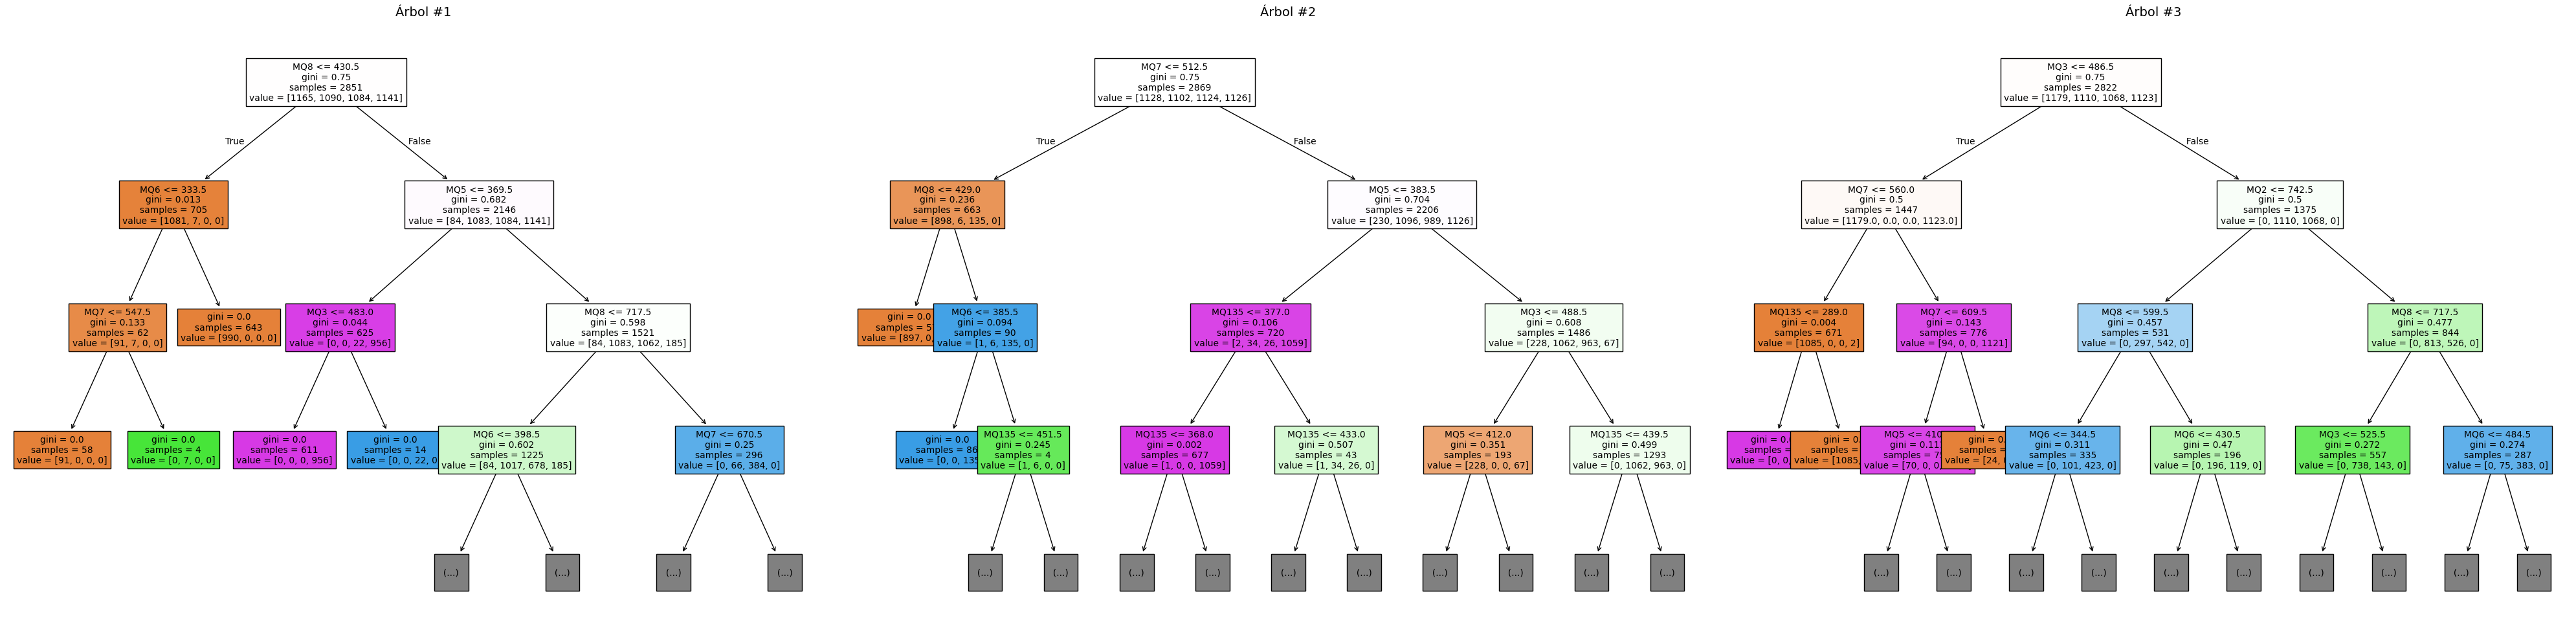

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 10))

# Recorrer los tres primeros árboles
for i in range(3):
    plot_tree(
        rf.estimators_[i],
        feature_names=X_train.columns,
        filled=True,
        max_depth=3,  # Limitar profundidad para mayor legibilidad
        fontsize=10,
        ax=axes[i]  # Plot en el subplot correspondiente
    )
    axes[i].set_title(f"Árbol #{i+1}", fontsize=14)

plt.tight_layout()
plt.show()

### **❓¿Qué podemos observar?**

**🌳 Árbol #1**

- Raíz: MQ8 <= 431.0, con 2851 muestras y gini = 0.75 → alta mezcla de clases.
- Rama izquierda (más pura): MQ6 <= 322.5, lleva a divisiones sucesivas donde se alcanza gini = 0.0 en varios nodos → predicciones muy precisas.
- Rama derecha explora MQ5, MQ3, MQ6 con gini descendente (≈0.4), lo que muestra segmentaciones efectivas.
- MQ8 y MQ6 aparecen en múltiples niveles → son relevantes para discriminar entre clases.

📌 Variables destacadas: MQ3, MQ5, MQ6, MQ2, MQ8

🌳 Árbol #2

- Raíz: MQ7 <= 505.5, con 2869 muestras y gini = 0.75 → mezcla considerable inicial.
- Rama izquierda (más pura): MQ8 <= 420 lleva a nodos con gini cercanos a cero.
- La rama derecha profundiza en MQ6, MQ3 y MQ135, con gini entre 0.0 y 0.5.
- MQ8 y MQ5 se repiten como nodos críticos en distintas ramas.

📌 Variables destacadas: MQ8, MQ7, MQ6, MQ3, MQ135

🌳 Árbol #3

- Raíz: MQ3 <= 486.0, con 2822 muestras y gini = 0.75 → nodo de alta diversidad inicial.
- La rama izquierda contiene divisiones altamente puras.
- Rama derecha explora principalmente MQ6 y MQ7 Y MQ135, con gini < 0.435en varios nodos → buena segmentación.
- MQ7 y MQ8 también aportan en niveles intermedios del árbol.

📌 Variables destacadas: MQ3, MQ7, MQ5, MQ6, MQ2, mq135

**🔍 Observaciones clave**
- MQ7, MQ8 y MQ6 se repiten en los tres árboles, lo que indica su importancia para refinar decisiones en distintas ramas.
- MQ135 destacan en árboles 2 y 3, aportando en divisiones con baja impureza.

Todos los árboles alcanzan nodos con gini = 0.0 → evidencia de que logran una alta especialización en ciertas regiones del espacio de características.

### Evaluación del modelo

#### Matriz de confusión

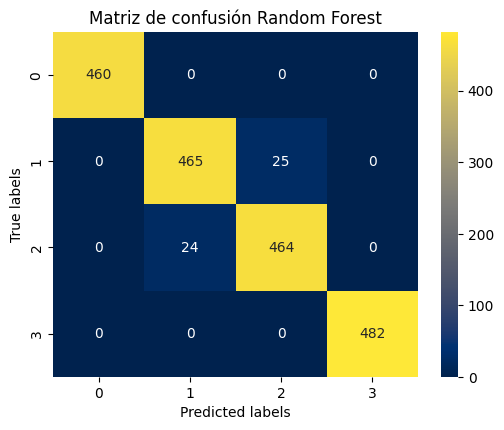

In [26]:
plot_multiple_conf_matrices([y_test],[y_rf_pred],['Matriz de confusión Random Forest'])

In [27]:
y_test.value_counts()

Gas
NoGas      490
Perfume    488
Smoke      482
Mixture    460
Name: count, dtype: int64

Donde las labels son:
- 0 : Mixture    
- 1 : NoGas      
- 2 : Perfume    
- 3 : Smoke


Vemos que el modelo diferencia perfectamente las clases 'Mixture' y 'Smoke', teniendo más dificultas al diferenciar 'No Gas' y 'Perfume'

#### ❓ ¿En el contexto de nuestro problema, afecta esta confusión?

#### Métricas de evaluación 

In [28]:
params_rf = rf.get_params()

In [29]:
pd_metricas_clasifier({'rf': [
    [params_rf['max_depth'],
     params_rf['min_samples_leaf'],
     params_rf['min_samples_split'],
     params_rf['criterion']],
     (y_test, y_rf_pred)] })

,Nombre_Modelo,Max_profundidad,Min_obs,Min_Obs_x_Sep,Criterio_Sep,Precision Test 1,Recall Test 1,Accuracy Test 1,F1-Score Test 1
0,rf,None,1,2,gini,0.97448,0.974479,0.974479,0.974479


**🟢 Interpretación:**
Todas las métricas son altas y prácticamente idénticas (~97.2%), lo cual sugiere que:
- El modelo predice muy bien las clases verdaderas a excepción de 1 y 2 que tienen una leve confusión.
- No hay un sesgo fuerte hacia ninguna clase (ya que precision y recall están equilibrados).
- El modelo es coherente, no solo acierta, sino que también lo hace con seguridad y balance entre sensibilidad y especificidad.

### Optimización de hiperparámetros.

Los hiperparámetros a optimizar son:
- n_estimators: números de árboles.
- Max depth (Maxima profundidad):
- min_samples_split: mínimo número de muestras para dividir un nodo.
- min_samples_leaf: numero mínimo de muestras con las que se puede quedar una hoja.
- criterion : criterio de división ['gini', 'entropy', 'log_loss']

Donde:
- Gini: mide el grado de impureza de un nodo. Un nodo con gini = 0 significa que solo tiene una clase.
- Entropy: También mide la impureza de un nodo, pero desde una perspectiva de la teoría de la información. Cuanto más “desordenado” está un grupo de datos (es decir, más mezcladas las clases), mayor es la entropía. Si todos los datos son de una sola clase, la entropía es 0.
- Log_loss: Es una forma de medir qué tan buenas son las probabilidades que predice un modelo de clasificación. No solo importa si acierta la clase, sino qué tan seguro estaba de su predicción. Qué castiga el log loss? Si el modelo se equivoca y está muy seguro → castigo grande. Si el modelo se equivoca pero no estaba tan seguro → castigo pequeño. Si acierta y estaba seguro → recompensa (log loss bajo). Porque no solo queremos saber si acierta la clase, sino también si sus predicciones de probabilidad son confiables.

In [ ]:
## Seteamos el campo de variación de cada variable.
param_grid = {
'n_estimators' : list(range(50,201,10)),
'max_depth' : list(range(5,51,5)),
'min_samples_split' : list(range(5,15,5)),
'min_samples_leaf' : list(range(0,6,1)),
'criterion' : ['gini','entropy']
}

**❓¿Cuántas combinaciones posibles hay?**

Para calcular la cantidad total de combinaciones posibles, simplemente multiplicamos la cantidad de elementos en cada lista:

- n_est: 50 a 200 con paso 10 → 16 valores
- max_d: 5 a 50 con paso 5 → 10 valores
- min_split: 5 a 15 con paso 5 → 2 valores ([5, 10])
- min_leaf: 0 a 5 con paso 1 → 6 valores ([0, 1, 2, 3, 4, 5])
- criter: (['gini', 'entropy']) → 3 valores 

Multiplicamos:

16 × 10 × 2 × 6 × 2 = 3840 combinaciones posibles

3840 combinaciones puede a priori no parecer un numero muy grande en términos de costos computacionales. Sin embargo, si agregásemos cross-validation este numero podría crecer en gran medida. Por ejemplo, con un cross-validation de 3, tendríamos ahora un total de 11.520 pruebas (notese que se aclara 'pruebas' y no combinaciones). 
Este análisis es importante hacerlo y nuestra decisión depende de los recursos que tengamos (tiempo, hardware, etc)

En este caso, utilizamos **optuna**. 

Optuna prueba diferentes combinaciones de parámetros, pero en lugar de hacerlo al azar (como RandomSearch) o probando todos los casos posibles (como GridSearch), va aprendiendo qué combinaciones dan mejores resultados y se enfoca en probar solo las más prometedoras.

¿Cómo lo hace?
- Define un espacio de búsqueda: el rango de valores posibles para cada hiperparámetro.
- Hace pruebas (llamadas “trials”): ejecuta el modelo con una combinación de parámetros.
- Evalúa el resultado (por ejemplo, con la precisión o el error).
- Usa ese resultado para mejorar la siguiente prueba, eligiendo parámetros más cerca de los que funcionaron mejor antes.

Optuna usa una técnica llamada **Optimización Bayesiana**, concretamente una variante conocida como TPE (Tree-structured Parzen Estimator). Esta técnica:

- Modela la relación entre los hiperparámetros y la métrica objetivo de forma probabilística.
- A partir de los resultados anteriores, estima dónde vale la pena buscar los siguientes valores.
- Así, prueba más donde hay alta probabilidad de mejora, sin necesidad de derivadas como el caso de una optimización por gradiente.

Si interesa ahondar en el tema: [https://optuna.org/#paper](https://optuna.org/#paper)

In [31]:
#!pip install optuna

In [80]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 750, step=50),  
        'max_depth': trial.suggest_int('max_depth', 5, 15, step=2),           
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=2),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestClassifier(**param)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        fold_scores.append(acc)

        print(f"Trial {trial.number} | Fold {fold+1} | Accuracy: {acc:.4f}")

    mean_acc = np.mean(fold_scores)
    std_acc = np.std(fold_scores)

    # Accuracy en test (solo para información)
    final_model = RandomForestClassifier(**param)
    final_model.fit(X_train, y_train)
    test_preds = final_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)

    print(f"Trial {trial.number} | Mean CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f} | Test Accuracy: {test_acc:.4f} | Params: {param}")

    return mean_acc  # Optuna maximiza este promedio de accuracy CV

# Ejecutar la optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)


[I 2025-11-07 19:56:25,295] A new study created in memory with name: no-name-ab35765a-525a-48c3-a467-331c18c7406b


Trial 0 | Fold 1 | Accuracy: 0.9442
Trial 0 | Fold 2 | Accuracy: 0.9520
Trial 0 | Fold 3 | Accuracy: 0.9676
Trial 0 | Fold 4 | Accuracy: 0.9643
Trial 0 | Fold 5 | Accuracy: 0.9609


[I 2025-11-07 19:56:35,861] Trial 0 finished with value: 0.9578125 and parameters: {'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 10, 'criterion': 'gini'}. Best is trial 0 with value: 0.9578125.


Trial 0 | Mean CV Accuracy: 0.9578 ± 0.0086 | Test Accuracy: 0.9578 | Params: {'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 10, 'criterion': 'gini'}
Trial 1 | Fold 1 | Accuracy: 0.9397
Trial 1 | Fold 2 | Accuracy: 0.9464
Trial 1 | Fold 3 | Accuracy: 0.9565
Trial 1 | Fold 4 | Accuracy: 0.9531
Trial 1 | Fold 5 | Accuracy: 0.9609


[I 2025-11-07 19:56:40,462] Trial 1 finished with value: 0.9513392857142857 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.9578125.


...

Trial 47 | Mean CV Accuracy: 0.9746 ± 0.0055 | Test Accuracy: 0.9734 | Params: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Trial 48 | Fold 1 | Accuracy: 0.9676
Trial 48 | Fold 2 | Accuracy: 0.9732
Trial 48 | Fold 3 | Accuracy: 0.9855
Trial 48 | Fold 4 | Accuracy: 0.9732
Trial 48 | Fold 5 | Accuracy: 0.9766


[I 2025-11-07 20:02:20,920] Trial 48 finished with value: 0.9752232142857142 and parameters: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 46 with value: 0.9761160714285715.


Trial 48 | Mean CV Accuracy: 0.9752 ± 0.0059 | Test Accuracy: 0.9740 | Params: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Trial 49 | Fold 1 | Accuracy: 0.9576
Trial 49 | Fold 2 | Accuracy: 0.9565
Trial 49 | Fold 3 | Accuracy: 0.9732
Trial 49 | Fold 4 | Accuracy: 0.9665
Trial 49 | Fold 5 | Accuracy: 0.9665


[I 2025-11-07 20:02:30,145] Trial 49 finished with value: 0.9640625 and parameters: {'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 7, 'criterion': 'entropy'}. Best is trial 46 with value: 0.9761160714285715.


Trial 49 | Mean CV Accuracy: 0.9641 ± 0.0062 | Test Accuracy: 0.9630 | Params: {'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 7, 'criterion': 'entropy'}


In [81]:
study.best_params

{'n_estimators': 350,
 'max_depth': 15,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'criterion': 'entropy'}

In [ ]:
rf_optuna = RandomForestClassifier(**study.best_params, random_state= 1)
rf_optuna.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=15, n_estimators=350,
                       random_state=1)

In [83]:
y_rf_optuna_pred = rf_optuna.predict(X_test)

In [84]:
pd_metricas_clasifier({'rf_optuna': [
    [study.best_params['max_depth'],
     study.best_params['min_samples_leaf'],
     study.best_params['min_samples_split'],
     study.best_params['criterion']],
     (y_test, y_rf_optuna_pred)] })

,Nombre_Modelo,Max_profundidad,Min_obs,Min_Obs_x_Sep,Criterio_Sep,Precision Test 1,Recall Test 1,Accuracy Test 1,F1-Score Test 1
0,rf_optuna,15,1,2,entropy,0.973439,0.973437,0.973437,0.973438


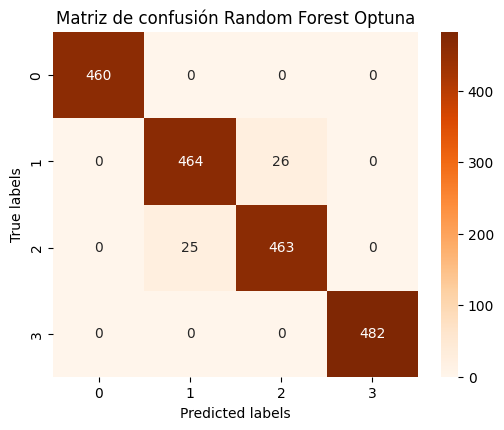

In [85]:
plot_multiple_conf_matrices([y_test],[y_rf_optuna_pred],['Matriz de confusión Random Forest Optuna'])

Este modelo logra diferenciar mejor entre 'Smoke' y 'Perfume' obteniendo un metricas de (~0.97.34). Sin embargo, queda un pequeño espacio para mejorar si ampliásemos el espacio de búsqueda de optuna. 

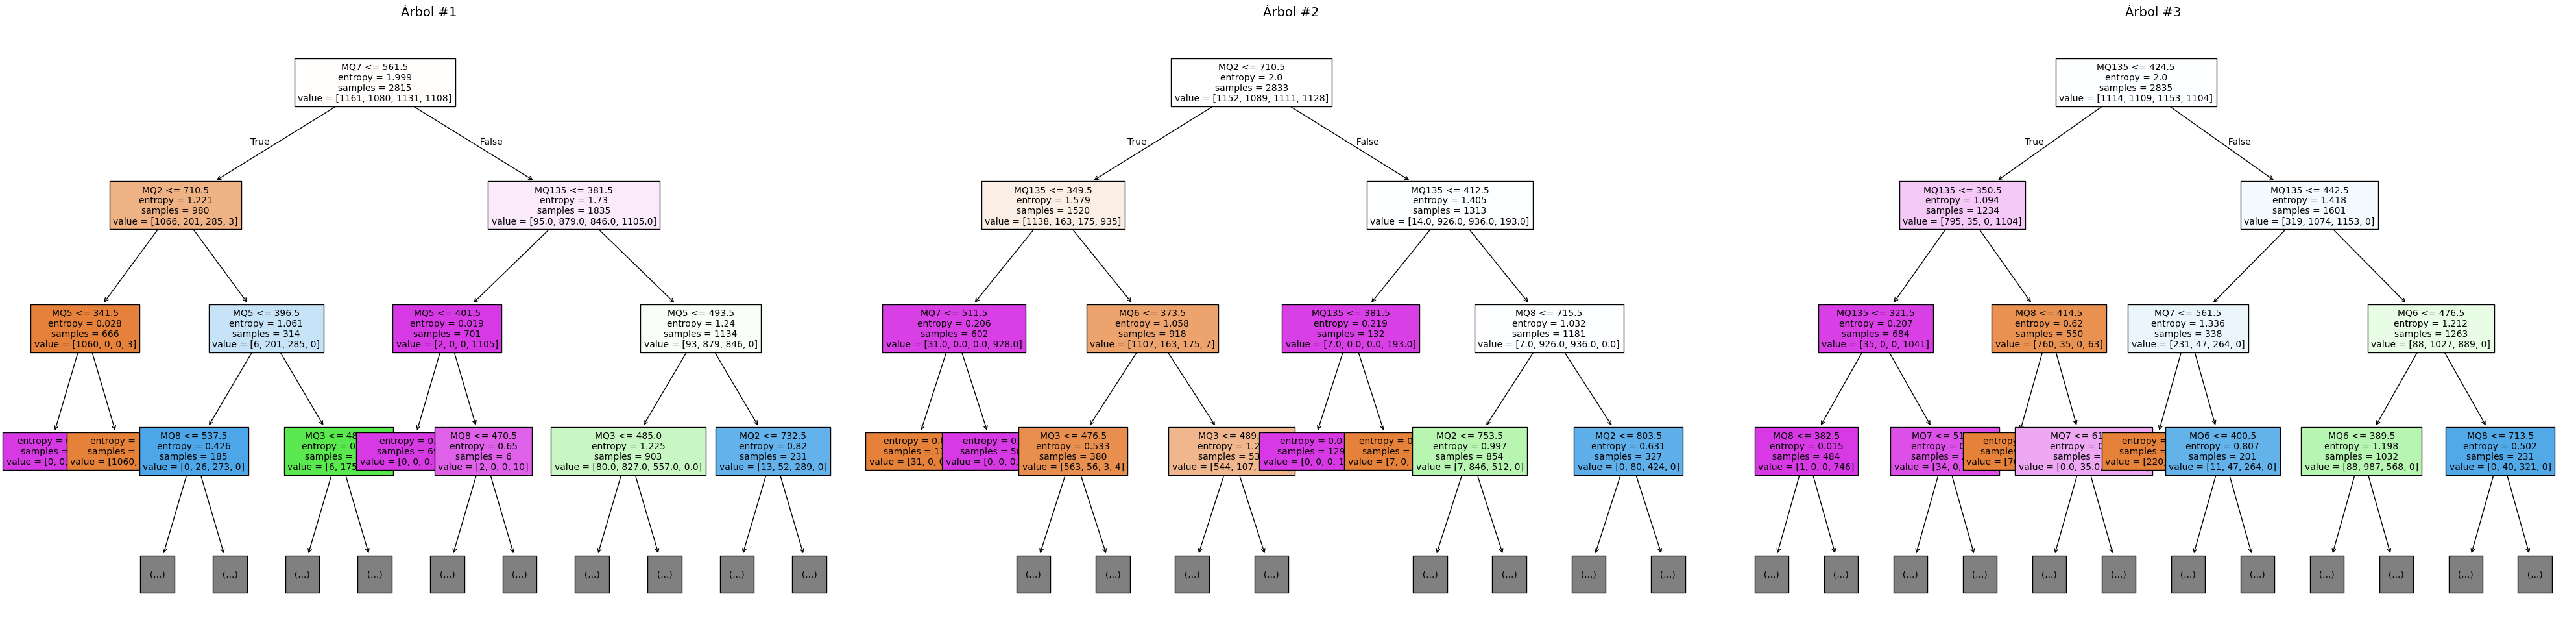

In [86]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 10))

# Recorrer los tres primeros árboles
for i in range(3):
    plot_tree(
        rf_optuna.estimators_[i],
        feature_names=X_train.columns,
        filled=True,
        max_depth=3,  # Limitar profundidad para mayor legibilidad
        fontsize=10,
        ax=axes[i]  # Plot en el subplot correspondiente
    )
    axes[i].set_title(f"Árbol #{i+1}", fontsize=14)

plt.tight_layout()
plt.show()

### Comparación de modelos.

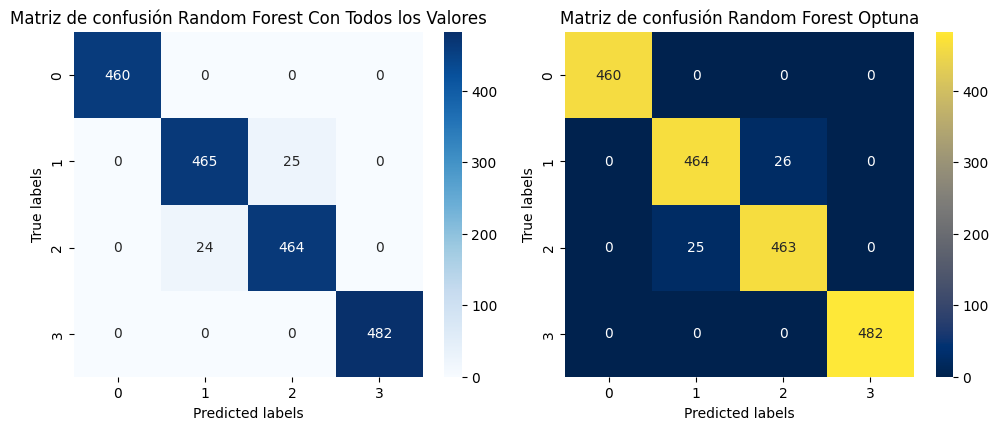

In [96]:
plot_multiple_conf_matrices([y_test,y_test],
                            [y_rf_pred,y_rf_optuna_pred],
                            ['Matriz de confusión Random Forest Con Todos los Valores',
                            
                             'Matriz de confusión Random Forest Optuna'])

In [87]:
pd_metricas_clasifier(
    dict_modelos = {
    'rf': [
    [params_rf['max_depth'],
     params_rf['min_samples_leaf'],
     params_rf['min_samples_split'],
     params_rf['criterion']],
     (y_test, y_rf_pred)],
     'rf_optuna': [
    [study.best_params['max_depth'],
     study.best_params['min_samples_leaf'],
     study.best_params['min_samples_split'],
     study.best_params['criterion']],
     (y_test, y_rf_optuna_pred)] 
    }
)

,Nombre_Modelo,Max_profundidad,Min_obs,Min_Obs_x_Sep,Criterio_Sep,Precision Test 1,Recall Test 1,Accuracy Test 1,F1-Score Test 1
0,rf,None,1,2,gini,0.974480,0.974479,0.974479,0.974479
0,rf_optuna,15,1,2,entropy,0.973439,0.973437,0.973437,0.973438


In [89]:
np.mean([tree.get_depth() for tree in rf.estimators_])

np.float64(17.88)

In [90]:
np.mean([tree.get_depth() for tree in rf_optuna.estimators_])

np.float64(14.971428571428572)

**✅ Observaciones:**
- El modelo rf_optuna (optimizando con Optuna) logra un rendimiento suavemente peor, aunque la diferencia es muy sutil respecto al modelo base. Esto puede deberse al espacio de búsqueda como también la canatidad de iteraciones.
- El modelo rf (original, sin filtrado ni tuning) ya estaba muy bien, pero tenía max_depth=None (árboles sin límite), lo cual puede aumentar el riesgo de overfitting.

Aunque las diferencias son pequeñas, el modelo ajustado con Optuna logra un leve aumento en todas las métricas, demostrando que una búsqueda inteligente de hiperparámetros puede mejorar un modelo ya sólido. Además, fija una profundidad máxima de 51, lo que podría ayudar a controlar el overfitting frente al modelo original sin límite de profundidad.

# Cross Validation

In [97]:
from sklearn.model_selection import cross_val_score, cross_validate


In [91]:
scores = cross_val_score(rf_optuna, X_test, y_test, cv = 5)
print(scores)

[0.95052083 0.953125   0.96354167 0.96614583 0.9765625 ]


In [92]:
print("%0.2f accuracy con una desviación estándar de %0.2f" % (scores.mean(), scores.std()))

0.96 accuracy con una desviación estándar de 0.01


In [93]:
scores_f1 = cross_val_score(rf_optuna, X_test, y_test, cv = 5, scoring='f1_macro')
scores_f1

array([0.95123588, 0.95381579, 0.96425221, 0.96682896, 0.97701149])

In [94]:
print("%0.2f f1-macro con una desviación estándar de %0.2f" % (scores_f1.mean(), scores_f1.std()))

0.96 f1-macro con una desviación estándar de 0.01


In [95]:
scores_f1_0 = cross_val_score(rf, X_test, y_test, cv = 5, scoring='f1_macro')
scores_f1_0

array([0.94601187, 0.95639191, 0.95914539, 0.969375  , 0.97190294])

In [102]:
cross_validate(rf_optuna, cv = 5, scoring=('f1_macro','accuracy'), X = X_train, y = y_train)

{'fit_time': array([1.18497777, 1.31468177, 1.20984745, 1.04381108, 1.11573434]),
 'score_time': array([0.04883432, 0.04992867, 0.03332758, 0.03341079, 0.03375983]),
 'test_f1_macro': array([0.97071834, 0.97297242, 0.97972603, 0.96404331, 0.97189592]),
 'test_accuracy': array([0.97098214, 0.97321429, 0.97991071, 0.96428571, 0.97209821])}